## Data loading and initial exploration

In [22]:
# Core
import pandas as pd
import numpy as np
from pathlib import Path
import re

# Interactive plotting (recommended)
import plotly.graph_objects as go
import plotly.express as px

pd.options.display.max_rows = 20
pd.options.display.width = 160

In [30]:
files = [
    Path("../data/timing/TEST 05.08.2025 10_45_44.txt"),
]

# sanity-check they exist
for p in files:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p.resolve()}")
files

[PosixPath('../data/timing/TEST 05.08.2025 10_45_44.txt')]

In [24]:
def normalize_value_str(s: str) -> str:
    """
    Fix idiosyncrasies like '-.123' -> '-0.123', '.123' -> '0.123'
    """
    s = s.strip()
    s = re.sub(r"(?<=^-)\.(\d+)", r"0.\1", s)  # -.123 -> -0.123
    s = re.sub(r"(?<!\d)\.(\d+)", r"0.\1", s)  #  .123 or .123 -> 0.123
    return s

def short_param(param: str) -> str:
    """
    Take 'ft0_dcs:ft0AverageTime.timeA' -> 'timeA'
    Fallbacks if '.' is absent.
    """
    param = param.strip()
    if "." in param:
        return param.split(".")[-1]
    if ":" in param:
        return param.split(":")[-1]
    return param

def parse_timestamp(day_str: str, time_str: str) -> pd.Timestamp:
    """
    Combine 'DD.MM.YYYY' + 'HH:MM:SS.fffffffff' into pandas Timestamp.
    """
    # pandas can handle up to ns precision with %f
    # Using exact format for speed & robustness
    dt_str = f"{day_str.strip()} {time_str.strip()}"
    return pd.to_datetime(dt_str, format="%d.%m.%Y %H:%M:%S.%f", dayfirst=True, errors="raise")

def load_one_file(path: Path) -> pd.DataFrame:
    """
    Load a single semicolon-separated file with columns:
    day;time;param;value
    Returns long-format DataFrame with columns: ['timestamp', 'param', 'value', 'source']
    """
    # read as raw strings first (no parsing)
    df = pd.read_csv(
        path,
        sep=";",
        header=None,
        names=["day", "time", "param", "value"],
        dtype=str,
        engine="python",
        comment="#",    # allow commented lines
        na_filter=False
    )

    # Parse / normalize
    ts = df.apply(lambda r: parse_timestamp(r["day"], r["time"]), axis=1)
    params = df["param"].map(short_param)

    # numeric value with quirks handled
    vals = df["value"].map(normalize_value_str).map(lambda s: s.replace(",", "."))  # just in case commas appear
    vals = pd.to_numeric(vals, errors="coerce")

    out = pd.DataFrame(
        {
            "timestamp": ts,
            "param": params,
            "value": vals,
            "source": str(path)
        }
    )

    # drop rows with unparsable values
    out = out.dropna(subset=["value"]).reset_index(drop=True)

    # if duplicate timestamp/param pairs exist, average them (you can change to 'last' if preferred)
    out = (
        out.groupby(["timestamp", "param", "source"], as_index=False)["value"]
           .mean()
           .sort_values("timestamp")
           .reset_index(drop=True)
    )
    return out

def load_files(paths) -> pd.DataFrame:
    """
    Load all files and concatenate to a unified long-format dataset.
    """
    parts = [load_one_file(p) for p in paths]
    unified = pd.concat(parts, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
    return unified

In [31]:
unified_df = load_files(files)
unified_df.head(10)

,timestamp,param,source,value
0,2025-05-29 14:24:55.488,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
1,2025-05-29 15:13:49.894,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.1
2,2025-05-29 15:18:50.881,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
3,2025-05-29 15:23:50.919,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
4,2025-05-29 15:28:50.963,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.1
5,2025-05-29 15:33:51.985,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
6,2025-05-29 15:38:52.035,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
7,2025-05-29 15:43:52.083,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
8,2025-05-29 15:48:52.098,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.2
9,2025-05-29 15:53:52.161,value,../data/timing/TEST 05.08.2025 10_45_44.txt,27.1


In [32]:
# pivot to wide: index=timestamp, columns=param, values=value
wide = (
    unified_df.pivot_table(
        index="timestamp",
        columns="param",
        values="value",
        aggfunc="mean"  # if duplicates exist after concat
    )
    .sort_index()
)

# Keep only timestamps present for ALL params (inner join effect)
wide_inner = wide.dropna(how="any")

print("Wide shape (all timestamps):", wide.shape, "| after inner-join (dropna):", wide_inner.shape)
wide_inner.head(10)

Wide shape (all timestamps): (22837, 1) | after inner-join (dropna): (22837, 1)


param,value
timestamp,
2025-05-29 14:24:55.488,27.2
2025-05-29 15:13:49.894,27.1
2025-05-29 15:18:50.881,27.2
2025-05-29 15:23:50.919,27.2
2025-05-29 15:28:50.963,27.1
2025-05-29 15:33:51.985,27.2
2025-05-29 15:38:52.035,27.2
2025-05-29 15:43:52.083,27.2
2025-05-29 15:48:52.098,27.2


In [27]:
corr = wide_inner.corr(method="pearson")
corr

param,timeA,timeC,vertexPosition
param,,,
timeA,1.000000,0.017466,-0.999997
timeC,0.017466,1.000000,-0.014854
vertexPosition,-0.999997,-0.014854,1.000000


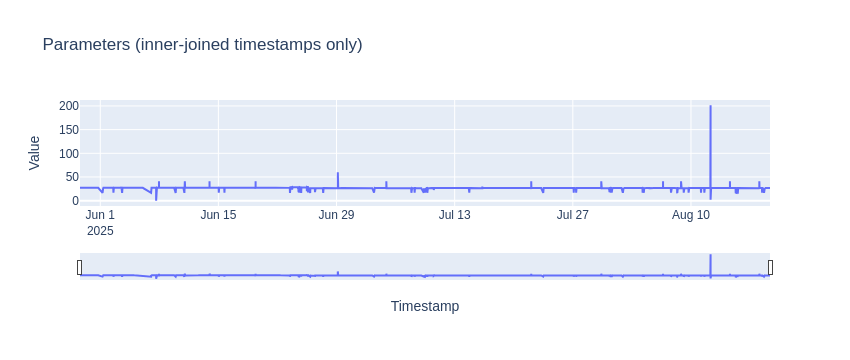

In [33]:
# Interactive lines with zoom/pan & range slider
fig = go.Figure()

for col in wide_inner.columns:
    fig.add_trace(go.Scatter(
        x=wide_inner.index,
        y=wide_inner[col],
        mode="lines",
        name=col
    ))

fig.update_layout(
    title="Parameters (inner-joined timestamps only)",
    xaxis_title="Timestamp",
    yaxis_title="Value",
    hovermode="x unified",
    xaxis=dict(rangeslider=dict(visible=True), type="date"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0)
)
fig.show()

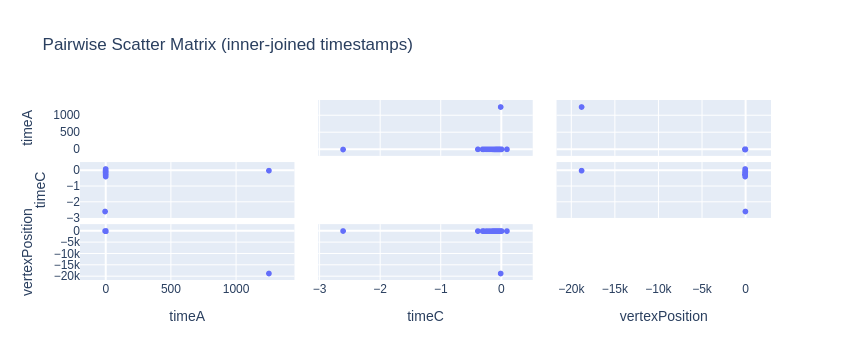

In [29]:
# For deeper comparison, a scatter matrix across params (may be heavy if many points)
sm = px.scatter_matrix(
    wide_inner.reset_index(drop=False),
    dimensions=list(wide_inner.columns),
    title="Pairwise Scatter Matrix (inner-joined timestamps)"
)
sm.update_traces(diagonal_visible=False)
sm.show()

## Feature engineering

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# === Optional sklearn imports (guarded) ===
try:
    from sklearn.preprocessing import StandardScaler, RobustScaler
    from sklearn.linear_model import HuberRegressor, LinearRegression
    from sklearn.ensemble import IsolationForest
    from sklearn.svm import OneClassSVM
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.model_selection import TimeSeriesSplit
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn not available. Only robust z-score and plotting will run.", e)

In [12]:
def ensure_input(df: pd.DataFrame) -> pd.DataFrame:
    must_have = {"timeA", "timeC", "vertexPosition"}
    if df is None:
        raise ValueError("`wide_inner` is not defined. Please ensure your data is loaded as a DataFrame named `wide_inner`.")
    missing = must_have.difference(df.columns)
    if missing:
        raise ValueError(f"`wide_inner` is missing columns: {missing}")
    if not isinstance(df.index, (pd.DatetimeIndex, pd.core.indexes.datetimes.DatetimeIndex)):
        raise TypeError("`wide_inner.index` must be a pandas.DatetimeIndex.")
    # Sort by time and drop duplicates
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    return df

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # Asymmetry and sum channels
    out["deltaT"] = out["timeA"] - out["timeC"]
    out["sumT"] = out["timeA"] + out["timeC"]
    # Magnitudes
    out["absA"] = out["timeA"].abs()
    out["absC"] = out["timeC"].abs()
    out["absDelta"] = out["deltaT"].abs()
    # Nonlinear terms (allow regression to capture curvature)
    out["deltaT2"] = out["deltaT"] ** 2
    out["sumT2"]  = out["sumT"] ** 2
    # Simple temporal derivatives (per-step finite differences)
    for col in ["timeA", "timeC", "vertexPosition", "deltaT", "sumT"]:
        out[f"d_{col}"] = out[col].diff()
    # Rolling statistics (change window to taste)
    window = 25  # number of samples (not seconds; resample first if needed)
    for col in ["timeA", "timeC", "vertexPosition", "deltaT", "sumT"]:
        out[f"rollMean_{col}"] = out[col].rolling(window, min_periods=max(3, window//3)).mean()
        out[f"rollStd_{col}"]  = out[col].rolling(window, min_periods=max(3, window//3)).std()
    # Drop initial NaNs from diffs/rolling for downstream models that need full rows
    out = out.dropna().copy()
    return out

In [13]:
def robust_z(x: pd.Series) -> pd.Series:
    """Robust z-score using median and MAD (scaled to be comparable to std if normal)."""
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        # Fallback to std if MAD is zero
        s = x.std(ddof=1)
        return (x - x.mean()) / (s if s > 0 else 1.0)
    return 0.67448975 * (x - med) / mad  # 0.67449 = inverse CDF of 0.75 for N(0,1)


def empirical_two_sided_p_from_scores(scores: pd.Series) -> pd.Series:
    """Convert centered scores to two-sided empirical p-values via ranks (distribution-free)."""
    # Use absolute value for two-sided tails
    v = scores.abs().rank(method="average") / (len(scores) + 1.0)
    # Larger |score| -> higher rank -> closer to 1 -> convert to tail prob
    # p = 1 - rank_cdf -> approximate two-sided tail probability
    p = 1 - v
    return p.clip(lower=0, upper=1)


def benjamini_hochberg(pvals: pd.Series, alpha=0.01) -> pd.Series:
    """Benjamini–Hochberg FDR control. Returns a boolean mask of discoveries."""
    m = len(pvals)
    order = np.argsort(pvals.values)
    sorted_p = pvals.values[order]
    thresh = alpha * (np.arange(1, m+1) / m)
    below = sorted_p <= thresh
    # Find largest k where p_(k) <= alpha * k/m
    if not below.any():
        return pd.Series(False, index=pvals.index)
    k = np.where(below)[0].max()
    cutoff = sorted_p[k]
    return pvals <= cutoff

In [14]:
def detect_robust_z_on_series(s: pd.Series, alpha=0.01):
    z = robust_z(s)
    p = empirical_two_sided_p_from_scores(z)
    is_anom = benjamini_hochberg(p, alpha=alpha)
    return pd.DataFrame({"score": z, "pval": p, "is_anom": is_anom})

def fit_huber_residuals(X: pd.DataFrame, y: pd.Series):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError("scikit-learn required for HuberRegressor.")
    scaler = RobustScaler()
    Xs = scaler.fit_transform(X.values)
    huber = HuberRegressor().fit(Xs, y.values)
    y_hat = huber.predict(Xs)
    resid = y.values - y_hat
    resid = pd.Series(resid, index=y.index, name="resid")
    return huber, scaler, resid

def detect_on_residuals(resid: pd.Series, alpha=0.01):
    z = robust_z(resid)
    p = empirical_two_sided_p_from_scores(z)
    is_anom = benjamini_hochberg(p, alpha=alpha)
    return pd.DataFrame({"score": z, "pval": p, "is_anom": is_anom})

def fit_iforest_scores(X: pd.DataFrame, contamination=0.01, random_state=0):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError("scikit-learn required for IsolationForest.")
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    model = IsolationForest(contamination=contamination, random_state=random_state)
    model.fit(Xs)
    # scikit-learn returns higher scores for more "normal" points via score_samples
    raw = model.score_samples(Xs)
    # Convert to "anomaly" score: lower score -> more anomalous
    score = pd.Series(-raw, index=X.index, name="iforest_score")
    return model, scaler, score

def fit_ocsvm_scores(X: pd.DataFrame, nu=0.01, gamma="scale"):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError("scikit-learn required for OneClassSVM.")
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    model = OneClassSVM(nu=nu, gamma=gamma)
    model.fit(Xs)
    raw = model.score_samples(Xs)
    score = pd.Series(-raw, index=X.index, name="ocsvm_score")
    return model, scaler, score

def fit_lof_scores_train_test(X: pd.DataFrame, train_ratio=0.7, n_neighbors=35):
    """
    Train novelty-LOF on the first `train_ratio` of samples, then score entire series.
    Returns a score series (higher -> more anomalous).
    """
    if not SKLEARN_AVAILABLE:
        raise RuntimeError("scikit-learn required for LOF.")
    n = len(X)
    split = int(n * train_ratio)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    scaler = StandardScaler().fit(X_train.values)
    X_train_s = scaler.transform(X_train.values)
    X_test_s  = scaler.transform(X_test.values)

    lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
    lof.fit(X_train_s)

    # score_samples: larger = more normal; invert for anomaly
    train_score = -pd.Series(lof.score_samples(X_train_s), index=X_train.index)
    test_score  = -pd.Series(lof.score_samples(X_test_s),  index=X_test.index)
    score = pd.concat([train_score, test_score]).sort_index()
    score.name = "lof_score"
    return lof, scaler, score

In [15]:
def plot_series_with_anomalies(ts: pd.Series, anom_mask: pd.Series, title: str):
    plt.figure(figsize=(12, 4))
    plt.plot(ts.index, ts.values, label=ts.name if ts.name else "series")
    if anom_mask.any():
        plt.scatter(ts.index[anom_mask], ts.values[anom_mask], marker='o', s=30, label="anomaly")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_score_over_time(score: pd.Series, title: str):
    plt.figure(figsize=(12, 3.5))
    plt.plot(score.index, score.values, label=score.name if score.name else "score")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
def inject_spikes(df: pd.DataFrame, col: str, frac=0.01, amplitude=3.0, random_state=0):
    """
    Create a copy with additive spikes in `col` on a random subset of timestamps.
    Returns (df2, anomaly_mask_index).
    """
    rng = np.random.default_rng(random_state)
    n = len(df)
    k = max(1, int(frac * n))
    idx = rng.choice(n, size=k, replace=False)
    df2 = df.copy()
    s = df2[col].values.copy()
    # amplitude scaled by robust std
    rstd = np.median(np.abs(s - np.median(s))) * 1.4826
    jumps = rng.choice([-1, 1], size=k) * amplitude * (rstd if rstd > 0 else 1.0)
    s[idx] = s[idx] + jumps
    df2[col] = s
    mask = pd.Series(False, index=df.index)
    mask.iloc[idx] = True
    return df2, mask

Display helper not available, showing head(): cannot import name 'display_dataframe_to_user' from 'caas_jupyter_tools' (/home/mvishiu11/default/lib/python3.12/site-packages/caas_jupyter_tools/__init__.py)
param           timeA  timeC  vertexPosition  deltaT  sumT  absDelta  d_vertexPosition
param                                                                                 
timeA           1.000  0.017          -1.000   1.000  1.00     1.000            -0.707
timeC           0.017  1.000          -0.015   0.015  0.02     0.013             0.002
vertexPosition -1.000 -0.015           1.000  -1.000 -1.00    -1.000             0.707
deltaT          1.000  0.015          -1.000   1.000  1.00     1.000            -0.707
sumT            1.000  0.020          -1.000   1.000  1.00     1.000            -0.707


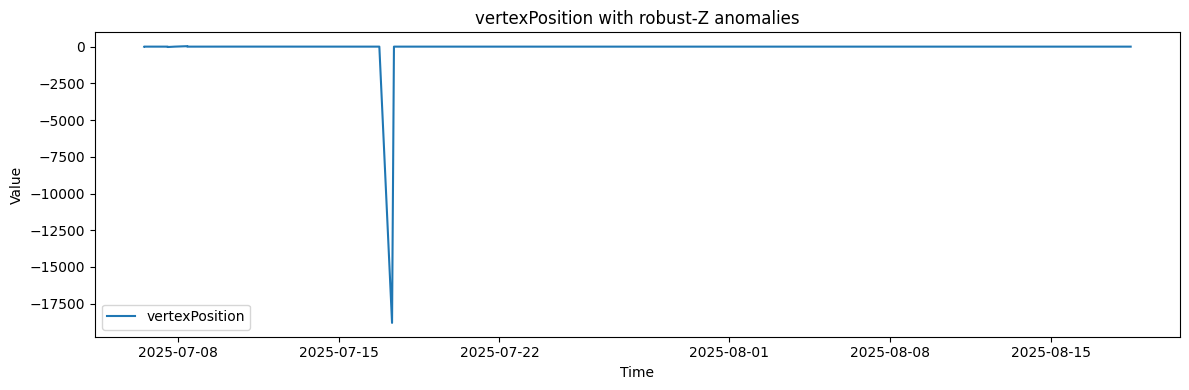

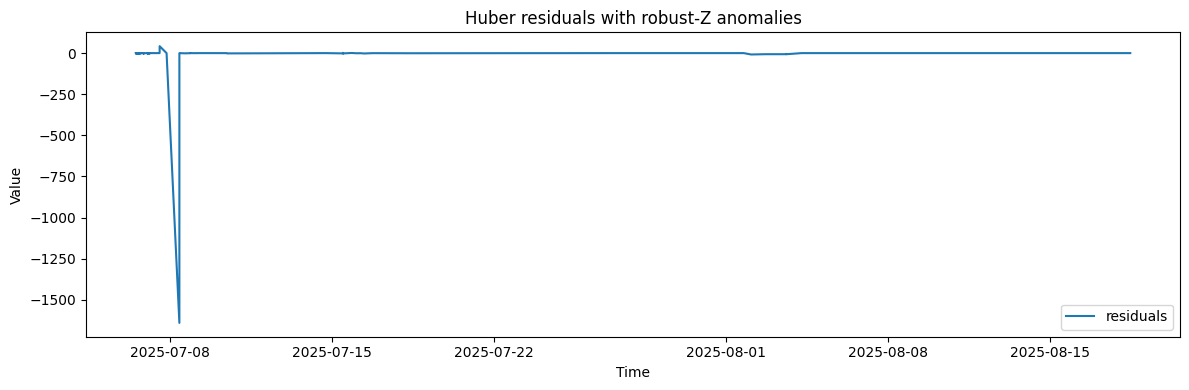

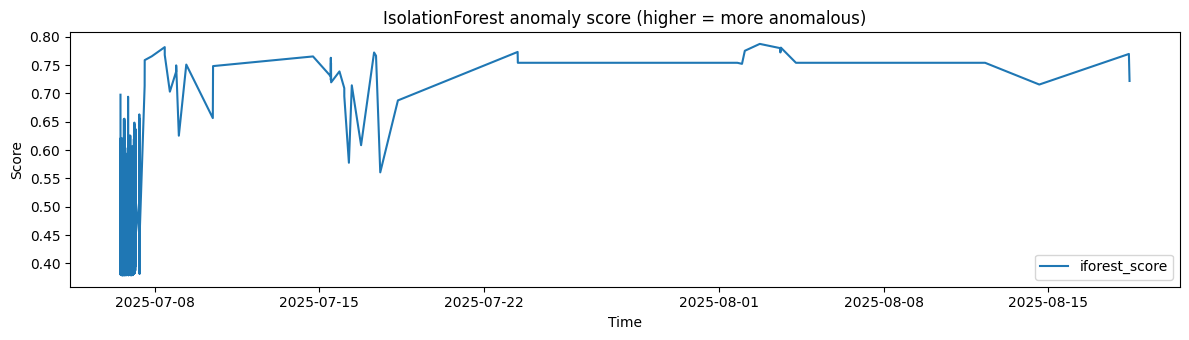

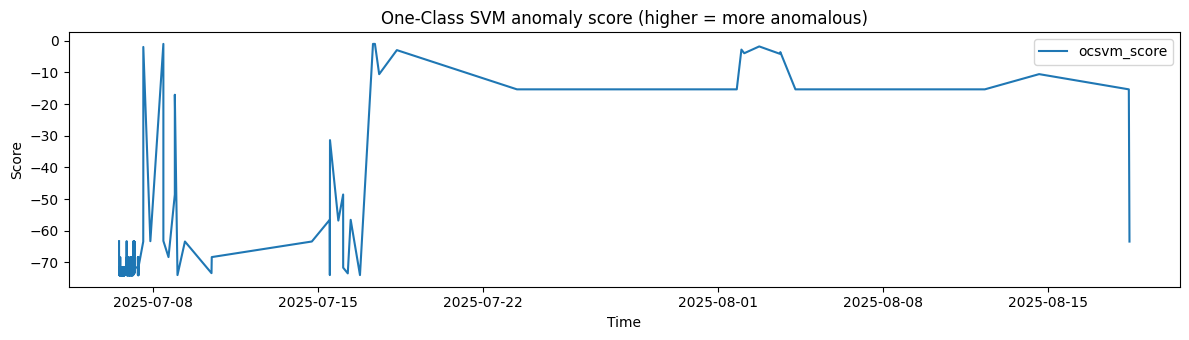

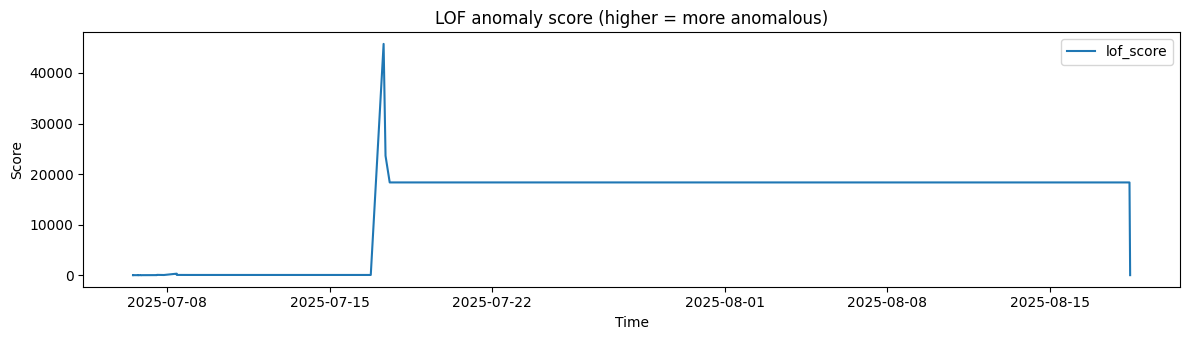

Saved results to: anomaly_outputs/anomaly_results_long.csv
Head:
                             score      pval  is_anom           method  series_value
timestamp                                                                          
2025-07-06 13:00:22.842 -6.070409  0.000872    False  robustZ(vertex)     -0.973672
2025-07-06 13:00:23.849 -4.046939  0.001781    False  robustZ(vertex)     -0.389469
2025-07-06 13:00:24.856 -5.395919  0.001090    False  robustZ(vertex)     -0.778938
2025-07-06 13:00:26.767 -4.721429  0.001272    False  robustZ(vertex)     -0.584203
2025-07-06 13:00:30.793 -4.046939  0.001781    False  robustZ(vertex)     -0.389469
Synth robust-Z: precision=0.000, recall=0.000


In [21]:
globals_dict = globals()
wide_inner_obj = globals_dict.get("wide_inner", None)

if wide_inner_obj is None:
    print("⚠️ `wide_inner` not found in this environment. "
          "Once your data is in a DataFrame named `wide_inner` with columns ['timeA','timeC','vertexPosition'] "
          "and a DatetimeIndex, re-run this cell.")
else:
    wide_inner = ensure_input(wide_inner_obj)

    # Feature engineering
    feats = engineer_features(wide_inner)

    # --- 2a) Quick correlations ---
    corr = feats[["timeA","timeC","vertexPosition","deltaT","sumT","absDelta","d_vertexPosition"]].corr()
    try:
        from caas_jupyter_tools import display_dataframe_to_user
        display_dataframe_to_user("Correlation (selected features)", corr.round(3))
    except Exception as e:
        print("Display helper not available, showing head():", e)
        print(corr.round(3).head())

    # --- 3a) Robust z-score on vertexPosition ---
    rz_vertex = detect_robust_z_on_series(feats["vertexPosition"], alpha=0.01)
    rz_vertex["method"] = "robustZ(vertex)"
    # Plot
    plot_series_with_anomalies(feats["vertexPosition"], rz_vertex["is_anom"], "vertexPosition with robust-Z anomalies")

    # --- 3b) Robust regression residuals (Huber): vertexPosition ~ deltaT + sumT + deltaT^2 + sumT^2 ---
    # If sklearn isn't available, this block is skipped
    results_list = []
    results_list.append(rz_vertex.assign(series_value=feats["vertexPosition"].values))

    if SKLEARN_AVAILABLE:
        X = feats[["deltaT","sumT","deltaT2","sumT2"]]
        y = feats["vertexPosition"]
        huber, huber_scaler, resid = fit_huber_residuals(X, y)
        rz_resid = detect_on_residuals(resid, alpha=0.01)
        rz_resid["method"] = "robustZ(residuals)"
        # Plot
        plot_series_with_anomalies(resid.rename("residuals"), rz_resid["is_anom"], "Huber residuals with robust-Z anomalies")
        results_list.append(rz_resid.assign(series_value=resid.values))

        # --- 3c) IsolationForest on multidimensional features ---
        X_if = feats[["timeA","timeC","deltaT","sumT","absDelta","d_vertexPosition","rollStd_vertexPosition"]].copy()
        X_if = X_if.replace([np.inf, -np.inf], np.nan).dropna()
        # align y for plotting
        iforest, if_scaler, if_score = fit_iforest_scores(X_if, contamination=0.01, random_state=0)
        p_if = empirical_two_sided_p_from_scores(if_score - if_score.median())
        is_if = benjamini_hochberg(p_if, alpha=0.01)
        df_if = pd.DataFrame({"score": if_score, "pval": p_if, "is_anom": is_if, "method": "IsolationForest"})
        # Plot score
        plot_score_over_time(if_score, "IsolationForest anomaly score (higher = more anomalous)")
        results_list.append(df_if.assign(series_value=feats.loc[if_score.index, "vertexPosition"].values))

        # --- 3d) One-Class SVM ---
        X_svm = X_if.copy()
        ocsvm, svm_scaler, svm_score = fit_ocsvm_scores(X_svm, nu=0.01, gamma="scale")
        p_svm = empirical_two_sided_p_from_scores(svm_score - svm_score.median())
        is_svm = benjamini_hochberg(p_svm, alpha=0.01)
        df_svm = pd.DataFrame({"score": svm_score, "pval": p_svm, "is_anom": is_svm, "method": "OneClassSVM"})
        plot_score_over_time(svm_score, "One-Class SVM anomaly score (higher = more anomalous)")
        results_list.append(df_svm.assign(series_value=feats.loc[svm_score.index, "vertexPosition"].values))

        # --- 3e) LOF (novelty) with temporal train/test split ---
        lof, lof_scaler, lof_score = fit_lof_scores_train_test(X_if, train_ratio=0.7, n_neighbors=35)
        p_lof = empirical_two_sided_p_from_scores(lof_score - lof_score.median())
        is_lof = benjamini_hochberg(p_lof, alpha=0.01)
        df_lof = pd.DataFrame({"score": lof_score, "pval": p_lof, "is_anom": is_lof, "method": "LOF(novelty)"})
        plot_score_over_time(lof_score, "LOF anomaly score (higher = more anomalous)")
        results_list.append(df_lof.assign(series_value=feats.loc[lof_score.index, "vertexPosition"].values))

    # --- Combine results ---
    all_results = pd.concat(results_list, axis=0)
    all_results.index.name = "timestamp"

    # Save & show
    out_dir = Path("./anomaly_outputs")
    out_dir.mkdir(parents=True, exist_ok=True)
    all_results.to_csv(out_dir / "anomaly_results_long.csv")
    try:
        from caas_jupyter_tools import display_dataframe_to_user
        display_dataframe_to_user("Anomaly results (long format)", all_results.reset_index())
    except Exception as e:
        print("Saved results to:", out_dir / "anomaly_results_long.csv")
        print("Head:\n", all_results.head())

    # --- Optional: synthetic injection demo (comment/uncomment) ---
    synth, true_mask = inject_spikes(feats, col="vertexPosition", frac=0.01, amplitude=4.0, random_state=123)
    rz_synth = detect_robust_z_on_series(synth["vertexPosition"], alpha=0.01)
    # Simple evaluation
    tp = int((rz_synth["is_anom"] & true_mask.loc[rz_synth.index]).sum())
    fp = int((rz_synth["is_anom"] & ~true_mask.loc[rz_synth.index]).sum())
    fn = int((~rz_synth["is_anom"] & true_mask.loc[rz_synth.index]).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    print(f"Synth robust-Z: precision={precision:.3f}, recall={recall:.3f}")